# Transfer Learning y Fine-Tuning

In [1]:
import json
import time
from io import BytesIO
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms.functional as F
from PIL import Image
from tqdm import tqdm

import csv
import os
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

First, let's check for a CUDA environment to make sure we can use GPU (or not) 

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

## Dataset

Then, we can construct our dataset. 

The dataset we made consists of:
- 30 images of class `bobby` (dog)
- 30 images of class `horchata` (cat)
- 30 images of class `empanada` (dog)
- 120 images of the control class `not_any`

For this, we can make our own dataset class that reads the CSV file with the labels. The CSV file has a `filename` and `class_idx` for each image, which we can convert to one entry in our dataset.

Items (images) are then constructed with `Image.open` and assumed to have 3 channels (RGB). Transformations are then applied

In [3]:
class FoodDataset(Dataset):
    def __init__(self, csv_path, images_dir, transform=None):
        self.images_dir = images_dir
        self.transform = transform
        with open(csv_path) as f:
            reader = csv.DictReader(f)
            self.samples = [(row["filename"], int(row["class_idx"])) for row in reader]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        img = Image.open(os.path.join(self.images_dir, fname)).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

The transformations used are the following:
- Resize to `224x224` pixels
- Convert `PILImage` to `Tensor`s
- Normalize the channel values to constrain them given the restrictions.

In [ ]:
transform = transforms.Compose([
      transforms.Resize((224, 224)),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
  ])

Once the transformations and our dataset model are in place, we can instantiate it with our metadata CSV, the image directory and the transformation (preprocessing) pipeline we created.

In [5]:
dataset = FoodDataset("data/labels.csv", "data/images", transform=transform)

Given the populated dataset instance, it has to be partitioned into `train`, `test` and `validation`. For this, we loop through the labels of all images and map them to their index so we have a relation `label -> idx`. This is useful so we can identify each image by its label in the stratification process.

We stratify the partitions because the size of this dataset is considerably smaller than an average-sized set, which means it is likely for categories to be heavily skewed and distributed improperly, and it's much more likely this causes a negative impact in our results. 

Once the dataset is partitioned in `80-10-10`, we load all the subsets.

In [ ]:
labels = [sample[1] for sample in dataset.samples]
indices = list(range(len(dataset)))

# train / test split
train_idx, temp_idx = train_test_split(
    indices, test_size=0.2, stratify=[labels[i] for i in indices], random_state=42
)

# val test
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=[labels[i] for i in temp_idx], random_state=42
)

train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)
test_set = Subset(dataset, test_idx)

Put them in a `DataLoader` to make them usable and shuffle `train` for better results.

In [ ]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set,   batch_size=32, shuffle=False)
test_loader = DataLoader(test_set,  batch_size=32, shuffle=False)

We can see that the partition was made successfully. Out of 210 images:
- 168 are for train (80%)
- 21 are for validation (10%)
- 21 are for test (10%)

In [8]:
print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
print(f"Classes: {{'bobby': 0, 'empanada': 1, 'horchata': 2, 'not_any': 3}}")

Train: 168 | Val: 21 | Test: 21
Classes: {'bobby': 0, 'empanada': 1, 'horchata': 2, 'not_any': 3}


In [9]:
num_classes = 4

## Pre-trained Models

For the model comparison, we will use two pre-trained models that will undergo a pipeline of transfer learning and fine tuning. For this, we create our own metric evaluation (accuracy) and training function.

Both of these functions can be referenced in our older notebooks.

`get_batch_accuracy` calculates the average accuracy of batches.

In [10]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

`train` iterates over the dataset `epoch` times, partitioning it in batches for every iteration.

In [11]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, _transforms=None):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }

    for epoch in range(_num_epochs):
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            _x = X_batch
            if _transforms is not None:
                _x = _transforms(_x)
            outputs = _model(_x)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        print(f"Epoch {epoch+1}/{_num_epochs} — "
              f"train_loss: {epoch_train_loss:.4f}  train_acc: {train_acc:.4f}  "
              f"val_loss: {epoch_val_loss:.4f}  val_acc: {val_acc:.4f}")

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

`plot_learning_curves` plots the loss and accuracy metrics of train against validation for contrast.

In [ ]:
def plot_learning_curves(res, title):
    epochs = range(1, len(res['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, res['train_loss'], label='Train')
    ax1.plot(epochs, res['val_loss'],   label='Validation')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(epochs, res['train_acc'], label='Train')
    ax2.plot(epochs, res['val_acc'],   label='Validation')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

### ResNet50

Our first model is **ResNet50**. It is an ImageNet-based model with (presumably) better performance than the baseline.

We can import it directly from `torchvision`.

In [13]:
from torchvision.models import resnet50
from torchvision.models import ResNet50_Weights

Its weights come bundled and contain the trainable parameters of the model.

In [14]:
weights = ResNet50_Weights.DEFAULT
model1 = resnet50(weights=weights)

model1.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

#### Transfer Learning

To apply transfer learning, we must first freeze all the parameters of the model.

In [15]:
# 2. Freeze all parameters
for param in model1.parameters():
    param.requires_grad = False

So we can then replace the classifier head (last layer) with our own. This is so the output can be constrained to our new classes (`bobby`, `horchata`, `empanada`, `not_any`).

In [16]:
# 3. Replace the final classifier (ResNet uses model.fc, not model.classifier)
model1.fc = nn.Linear(model1.fc.in_features, num_classes)

And finally train it using an optimizer (`Adam`) and a loss criterion (`CrossEntropyLoss`, multi-class) appropriate for the problem.

In [17]:
optimizer = torch.optim.Adam(model1.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
num_epochs = 5

In [18]:
res = train(model1, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch 1/5 — train_loss: 1.2654  train_acc: 0.5179  val_loss: 1.0439  val_acc: 0.5714
Epoch 2/5 — train_loss: 0.9052  train_acc: 0.5833  val_loss: 0.8096  val_acc: 0.6190
Epoch 3/5 — train_loss: 0.6952  train_acc: 0.7321  val_loss: 0.6306  val_acc: 0.8095
Epoch 4/5 — train_loss: 0.5261  train_acc: 0.8869  val_loss: 0.5032  val_acc: 0.9524
Epoch 5/5 — train_loss: 0.4026  train_acc: 0.9702  val_loss: 0.4217  val_acc: 1.0000


Finally, we save the model before doing anything else so it can be retrieved later.

In [ ]:
res_resnet_tl = res
torch.save(model1.state_dict(), 'resnet50_tl.pth')

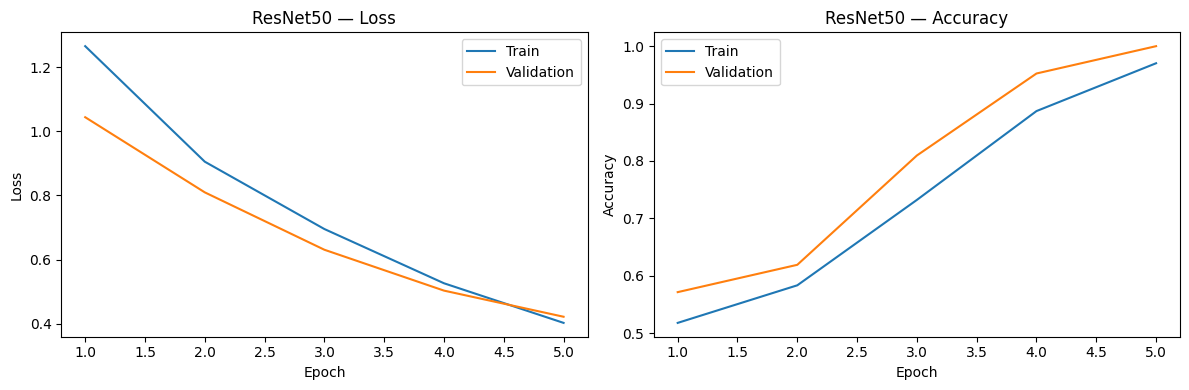

In [20]:
plot_learning_curves(res, title="ResNet50")

As can be seen above, the preliminary results show that accuracy increased progressively until reaching `100%` for validation. This adds up with the results of the loss graph. In a future section we explain the contrast, significance and meaning of this, while comparing it to the second model we evaluate.

#### Fine Tuning

Furthermore, we can fine-tune the model to get even better results. We have "re-trained" it using transfer learning to adapt it to our needs, but we can now selectively train particular layers to get even better prediction metrics.

Once again, first, we can freeze every parameter (of all layers) before we retrain the model. This is because we don't want to modify them at all and lose the "pre" in "pre-trained".

Following that, we can enable the layers that we *do* want to train which, in our case, is the very last layer and the fourth layer. We can iterate over their parameters and unfreeze them.

In [21]:
# all
for param in model1.parameters():
    param.requires_grad = False

# layer 4
for param in model1.layer4.parameters():
    param.requires_grad = True

# last layer
for param in model1.fc.parameters():
    param.requires_grad = True


To visualize how many parameters, we can add up all of the ones that aren't frozen. This is important to understand how training time differs to an untrained model.

In [22]:
trainable = sum(p.numel() for p in model1.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model1.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Trainable params: 14,972,932 / 23,516,228


Once again, we define the optimizer but, in this case, it defines learning rates for the additional layers we trained. They can be distinct and should be, as the pre-trained layer can advance slower than the layer we inserted (as it needs to be trained from scratch).

In [23]:
ft_optimizer = torch.optim.Adam([
    {"params": model1.layer4.parameters(), "lr": 1e-5}, # Pre-trained: low LR
    {"params": model1.fc.parameters(),  "lr": 1e-3}, # New head: normal LR
])
ft_num_epochs = 5

In [24]:
res_ft = train(model1, train_loader, val_loader, criterion, ft_optimizer, ft_num_epochs)

Epoch 1/5 — train_loss: 0.3084  train_acc: 0.9881  val_loss: 0.2943  val_acc: 1.0000
Epoch 2/5 — train_loss: 0.2029  train_acc: 0.9821  val_loss: 0.2260  val_acc: 1.0000
Epoch 3/5 — train_loss: 0.1347  train_acc: 0.9940  val_loss: 0.1852  val_acc: 1.0000
Epoch 4/5 — train_loss: 0.0821  train_acc: 1.0000  val_loss: 0.1407  val_acc: 1.0000
Epoch 5/5 — train_loss: 0.0600  train_acc: 1.0000  val_loss: 0.1124  val_acc: 1.0000


Finally, we save the model again for future use.

In [ ]:
res_resnet_ft = res_ft
torch.save(model1.state_dict(), 'resnet50_ft.pth')

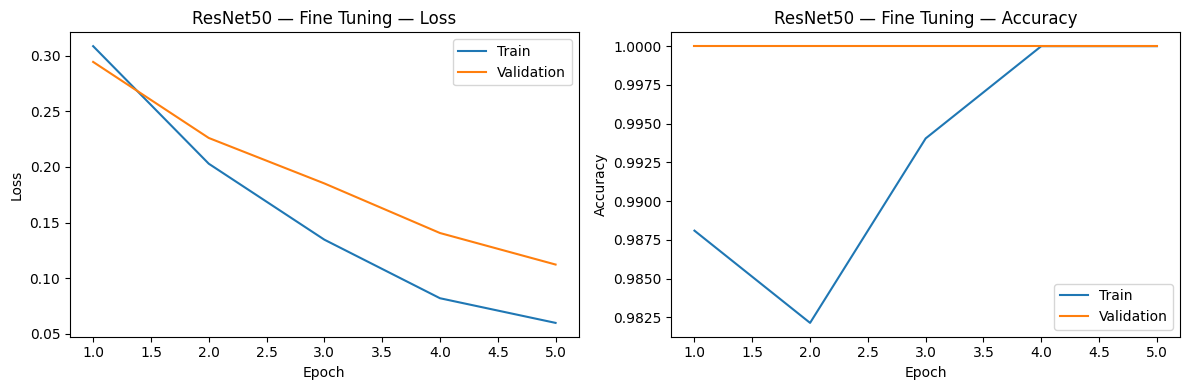

In [ ]:
plot_learning_curves(res_ft, title="ResNet50 - Fine Tuning")

### EfficientNet

In [27]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights


weights = EfficientNet_B0_Weights.DEFAULT
model2 = efficientnet_b0(weights=weights)    

model2.to(device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

#### Transfer Learning

In [28]:
for param in model2.parameters():
    param.requires_grad = False

In [29]:
model2.classifier[-1] = nn.Linear(model2.classifier[-1].in_features, num_classes)

In [30]:
optimizer = torch.optim.Adam(model2.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
num_epochs = 5

In [31]:
res = train(model2, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch 1/5 — train_loss: 1.3301  train_acc: 0.4405  val_loss: 1.1131  val_acc: 0.5238
Epoch 2/5 — train_loss: 0.9925  train_acc: 0.6190  val_loss: 0.9558  val_acc: 0.6667
Epoch 3/5 — train_loss: 0.8170  train_acc: 0.7143  val_loss: 0.8244  val_acc: 0.7619
Epoch 4/5 — train_loss: 0.6665  train_acc: 0.7798  val_loss: 0.7376  val_acc: 0.7619
Epoch 5/5 — train_loss: 0.5426  train_acc: 0.8929  val_loss: 0.6397  val_acc: 0.8571


In [32]:
#save results before overwrite, or evaluation can fail
res_eff_tl = res
torch.save(model2.state_dict(), 'effnet_tl.pth')

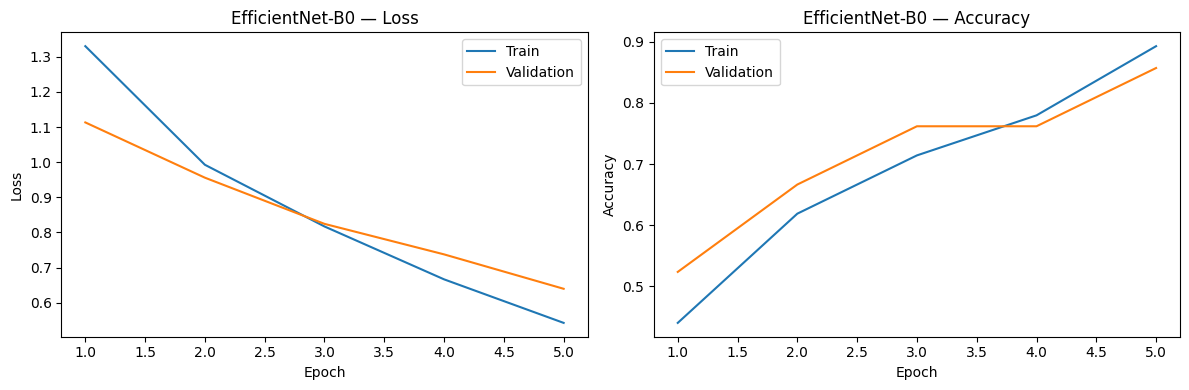

In [33]:
plot_learning_curves(res, title="EfficientNet-B0")

#### Fine Tuning

In [34]:
for param in model2.parameters():
    param.requires_grad = False

# Unfreeze the last few layers of the feature extractor 
for param in model2.features[7:].parameters():
    param.requires_grad = True

# Unfreeze the classifier head
for param in model2.classifier.parameters():
    param.requires_grad = True

In [35]:
ft_optimizer = torch.optim.Adam([
    {"params": model2.features[7:].parameters(), "lr": 1e-5}, # Pre-trained: low LR
    {"params": model2.classifier.parameters(), "lr": 1e-3}, # New head: normal LR   
])

In [36]:
ft_num_epochs = 5

In [37]:
res_ft = train(model2, train_loader, val_loader, criterion, ft_optimizer, ft_num_epochs)

Epoch 1/5 — train_loss: 0.4507  train_acc: 0.8929  val_loss: 0.5466  val_acc: 0.9048
Epoch 2/5 — train_loss: 0.3423  train_acc: 0.9702  val_loss: 0.4572  val_acc: 0.9524
Epoch 3/5 — train_loss: 0.2733  train_acc: 0.9821  val_loss: 0.3989  val_acc: 0.9524
Epoch 4/5 — train_loss: 0.2127  train_acc: 0.9940  val_loss: 0.3459  val_acc: 0.9524
Epoch 5/5 — train_loss: 0.2058  train_acc: 0.9821  val_loss: 0.3155  val_acc: 0.9524


In [38]:
#save results before overwrite, or evaluation can fail
res_eff_ft = res_ft
torch.save(model2.state_dict(), 'effnet_ft.pth')

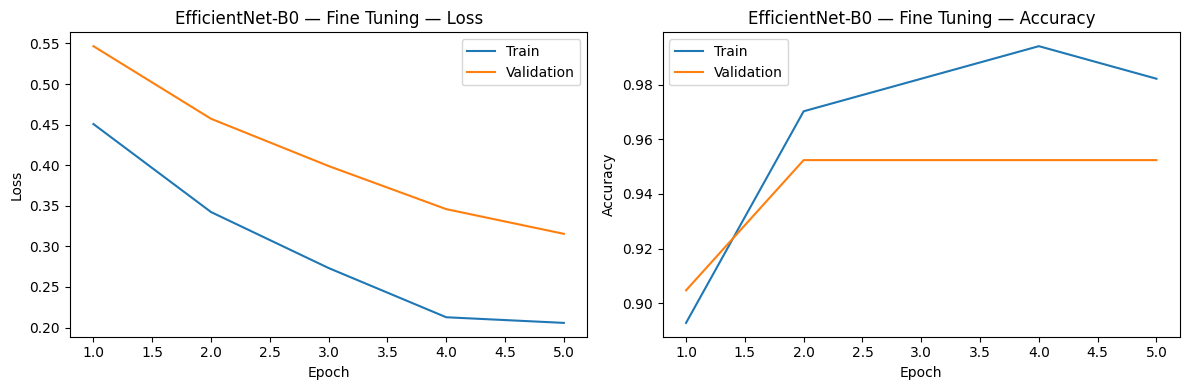

In [39]:
plot_learning_curves(res_ft, title="EfficientNet-B0 — Fine Tuning")

## Evaluation and Comparison

The validation loss and accuracy curves for all four configurations are plotted to see how they change during training and to help identify which one performs best.

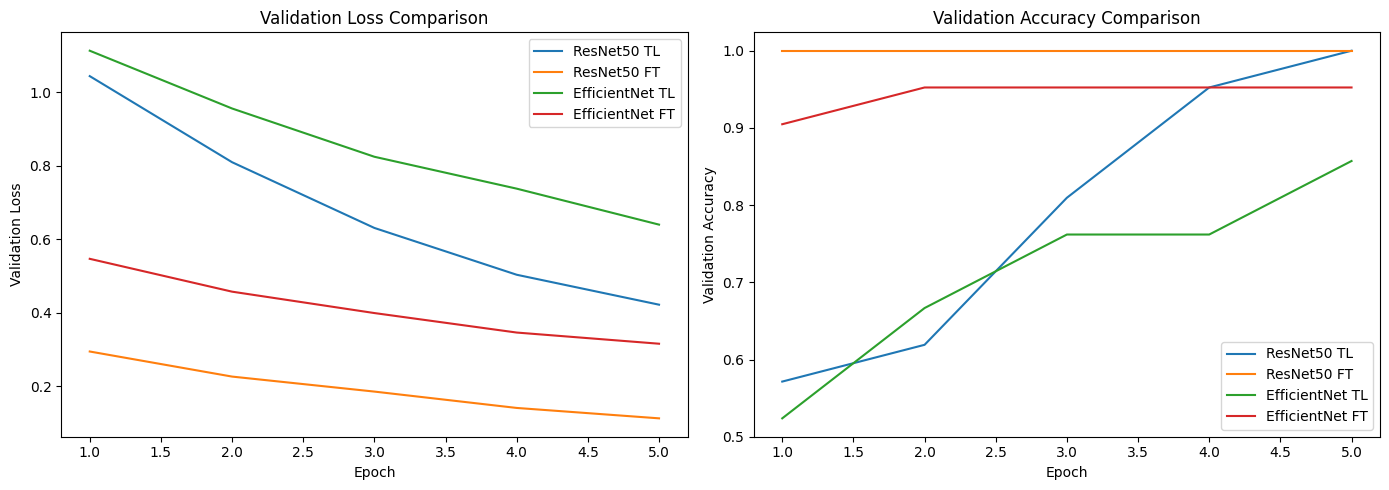

In [40]:
all_results = {
    'ResNet50 TL': res_resnet_tl,
    'ResNet50 FT': res_resnet_ft,
    'EfficientNet TL': res_eff_tl,
    'EfficientNet FT': res_eff_ft,
}

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for name, r in all_results.items():
    ep = range(1, len(r['val_loss']) + 1)
    axs[0].plot(ep, r['val_loss'], label=name)
    axs[1].plot(ep, r['val_acc'],  label=name)

axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Validation Loss')
axs[0].set_title('Validation Loss Comparison')
axs[0].legend()

axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Validation Accuracy')
axs[1].set_title('Validation Accuracy Comparison')
axs[1].legend()

plt.tight_layout()
plt.show()

Looking at the validation loss curves,the models with fine-tuning drop faster and reach lower values than the transfer learning ones, which makes sense since more parameters are being adjusted to the dataset. On the accuracy side, transfer learning already performs well from the start,but fine-tuning improves it a bit more.the difference is more noticeable in the loss than in accuracy,suggesting that fine-tuning mostly helps the model become more confident in its predictions.

### Model Comparison

The final validation accuracy and loss for all four configurations are compared to select the best model for test evaluation.

In [41]:
print(f"{'Model':<25} {'Val Loss':>10} {'Val Acc':>10}")
print('-' * 47)

best_name = None
best_acc = -1

for name, r in all_results.items():
    final_loss = r['val_loss'][-1]
    final_acc  = r['val_acc'][-1]
    print(f"{name:<25} {final_loss:>10.4f} {final_acc:>10.4f}")
    if final_acc > best_acc:
        best_acc = final_acc
        best_name = name

print(f"\nBest model: {best_name} with {best_acc:.4f} validation accuracy")

Model                       Val Loss    Val Acc
-----------------------------------------------
ResNet50 TL                   0.4217     1.0000
ResNet50 FT                   0.1124     1.0000
EfficientNet TL               0.6397     0.8571
EfficientNet FT               0.3155     0.9524

Best model: ResNet50 TL with 1.0000 validation accuracy


As can be seen from the final validation results, ResNet50 with fine-tuning reaches a validation accuracy of 1.0 in the last epochs and also achieves the lowest validation loss. In general, the models with fine-tuning perform better than those using transfer learning. By allowing the last convolutional layers to update with a low learning rate,the model can better adjust its more complex features to fit the patterns in this dataset, something that doesnt happen when all layers are kept fixed. Because of this, ResNet50 Fine-Tunning is chosen as the best model for the final test evaluation.

## Best Model Evaluation on Test Set

Based on the final validation accuracy, the best model is selected and evaluated once on the test set. 

In [42]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

checkpoint_map = {
    'ResNet50 TL': (model1, 'resnet50_tl.pth'),
    'ResNet50 FT': (model1, 'resnet50_ft.pth'),
    'EfficientNet TL': (model2, 'effnet_tl.pth'),
    'EfficientNet FT': (model2, 'effnet_ft.pth'),
}

best_model_arch, best_ckpt = checkpoint_map[best_name]
best_model_arch.load_state_dict(torch.load(best_ckpt, map_location=device))
best_model_arch.to(device)
best_model_arch.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = best_model_arch(X_batch)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = np.mean(all_preds == all_labels)
print(f'Best model: {best_name}')
print(f'Test accuracy: {test_acc:.4f}')

Best model: ResNet50 TL
Test accuracy: 1.0000


ResNet50 with fine-tuning achieved the best test accuracy. The fact that the test result is very close to the validation accuracy shows that the model generalizes well. This gives a reliable idea of how the model would perform on a new data

### Classification Report

With the best model selected, a classification report is generated on the test set 
including precision, recall, and F1-score.

In [43]:
class_names = ['bobby', 'empanada', 'horchata', 'not_any']

print(classification_report(all_labels, all_preds, target_names=class_names, labels=range(len(class_names))))

              precision    recall  f1-score   support

       bobby       1.00      1.00      1.00         3
    empanada       1.00      1.00      1.00         3
    horchata       1.00      1.00      1.00         3
     not_any       1.00      1.00      1.00        12

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



Looking at the results, the model performs consistently across all classes.Precision and recall are high for most categories,so it doesn’t seem to be favoring any specific class. The overall accuracy also matches what we saw on the test set,which shows the resultsare consistent. Its also important note that the score 1.00 are expected given the small size of the test set. With only a few samples class and clear visual differences between them, pretrained models can classify them without much difficulty.

### Confusion Matrix

The confusion matrix gives a more detailed view of where the model makes mistakes, 
showing which classes get confused with each other.

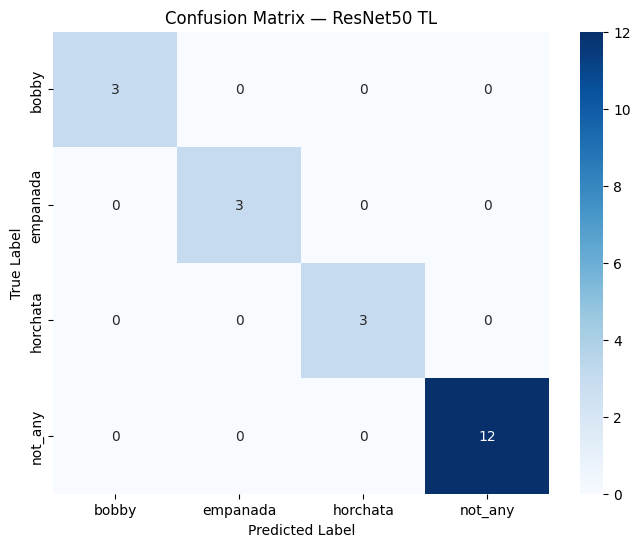

In [44]:
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

The diagonal shows that most samples are classified correctly. The few values outside the diagonal show where the model gets confused,which is expected since many of the images share similar shapes and colors

## Personal Reflection

In conclusion, this activity made it clear that transfer learning is a great starting point, but fine-tuning gives better results. Letting the last layers adjust to the dataset improves both accuracy and loss, especially with a small dataset like this. Overall, pretrained models make the process much faster and more effective.